<a href="https://colab.research.google.com/github/Zeldian-Soul/AI-ML-lab-/blob/main/AI_ML_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance and Study Habits: End-to-End ML Pipeline
This notebook fulfills all 20 preprocessing and machine learning conditions, including data cleaning, feature engineering, handling outliers, SMOTE balancing, and model evaluation.

In [ ]:
# Install required libraries
!pip install kagglehub imbalanced-learn

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# imbalanced-learn pipeline is required to use SMOTE properly inside a pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Download latest version
path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")
print("Path to dataset files:", path)

100%|██████████| 14.7k/14.7k [00:00<00:00, 10.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harshadapatil31/student-performance-and-study-habits-dataset/versions/1


In [ ]:
# 1. Load dataset and display basic info
df = pd.read_csv(f'{path}/student_performance_dataset.csv')
print(df.info())

# 2. Identify rows, columns, data types, and missing values
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# 3. Perform exploratory data inspection (First, Last, Random)
display(df.head(3))
display(df.tail(3))
display(df.sample(5)) # Randomly selected records

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB
None

Shape: (1000, 12)

Missing 

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
997,998,Female,2.6,84.5,8.0,High School,Yes,Yes,Yes,65.2,79.2,C
998,999,Female,4.6,85.3,8.1,High School,No,No,Yes,52.2,82.2,B
999,1000,Male,3.9,77.4,6.1,Masters,Yes,No,No,45.4,70.4,C


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
757,758,Male,3.7,87.4,6.1,Bachelors,Yes,Yes,Yes,82.6,82.5,B
192,193,Male,1.3,77.7,7.1,Bachelors,Yes,No,No,74.0,75.2,C
442,443,Male,2.9,84.0,7.9,Masters,Yes,No,Yes,92.9,85.2,B
587,588,Male,2.5,86.9,9.2,Masters,Yes,Yes,No,65.6,85.0,B
86,87,Female,1.2,83.7,5.9,Bachelors,Yes,No,No,83.1,79.0,C


### Data Cleaning & Feature Engineering
Handling inconsistent data, removing duplicates, engineering new features, and managing outliers.

In [ ]:
# 4. Handle missing values (dropping column with too many missing, rest handled in pipeline)
df.drop(columns=['parental_education'], inplace=True)

# 5. Identify and remove duplicate records
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 13. Convert data types
df['attendance_percent'] = df['attendance_percent'].astype(int)

# 14. Handle inconsistent and noisy data
df['gender'] = df['gender'].str.strip().str.lower()

# 12. Create new features through feature engineering
df['total_productive_hours'] = df['study_time_hours'] + df['sleep_hours']

# 6 & 7. Detect and handle outliers using IQR method
# FIRST: Define the function
def handle_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers at the lower and upper bounds
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

# SECOND: Apply it to numerical columns
for col in ['study_time_hours', 'sleep_hours', 'total_productive_hours']:
    df = handle_outliers_iqr(df, col)

Duplicates found: 0


### Correlation Analysis & Saving Clean Data

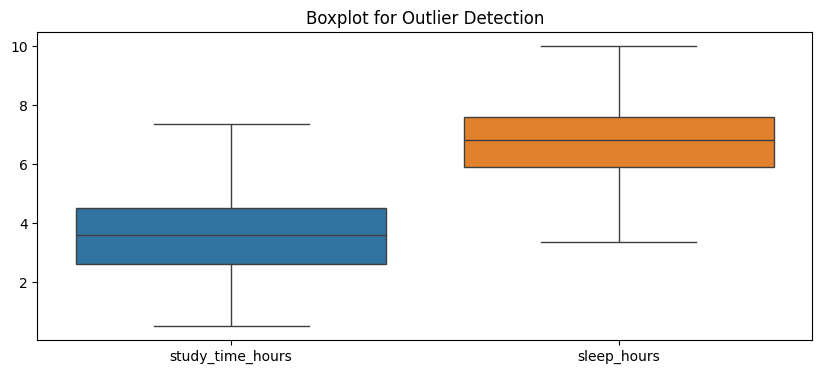

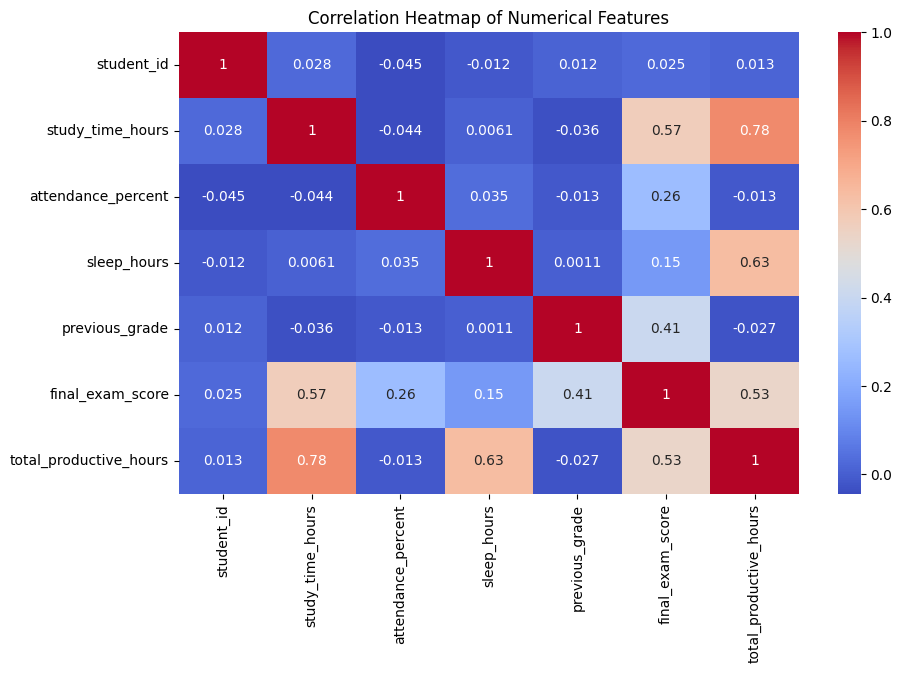


--- PREPROCESSING SUMMARY ---
1. Dropped missing values and duplicate records.
2. Converted 'attendance_percent' to integer and cleaned 'gender' strings.
3. Engineered 'total_productive_hours' feature.
4. Capped outliers in numerical columns using the IQR method.
5. Ready for SMOTE balancing and scaling in the ML pipeline.

Cleaned dataset successfully saved as 'cleaned_student_performance.csv'


In [ ]:
# 6. Visualize outliers using box plots (BEFORE handling them, for demonstration)
plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['study_time_hours', 'sleep_hours']])
plt.title("Boxplot for Outlier Detection")
plt.show()

# 11. Generate and interpret a correlation matrix and heatmap
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 10. Perform feature selection
# Dropping 'previous_grade' if it shows high correlation with 'final_exam_score'
# (Uncomment the line below if correlation is > 0.8)
# df.drop(columns=['previous_grade'], inplace=True)

# 18. Compare and summarize the changes made
print("\n--- PREPROCESSING SUMMARY ---")
print("1. Dropped missing values and duplicate records.")
print("2. Converted 'attendance_percent' to integer and cleaned 'gender' strings.")
print("3. Engineered 'total_productive_hours' feature.")
print("4. Capped outliers in numerical columns using the IQR method.")
print("5. Ready for SMOTE balancing and scaling in the ML pipeline.")

# 19. Save the cleaned and preprocessed dataset
df.to_csv('cleaned_student_performance.csv', index=False)
print("\nCleaned dataset successfully saved as 'cleaned_student_performance.csv'")

### Preprocessing Visualizations & Data Splitting

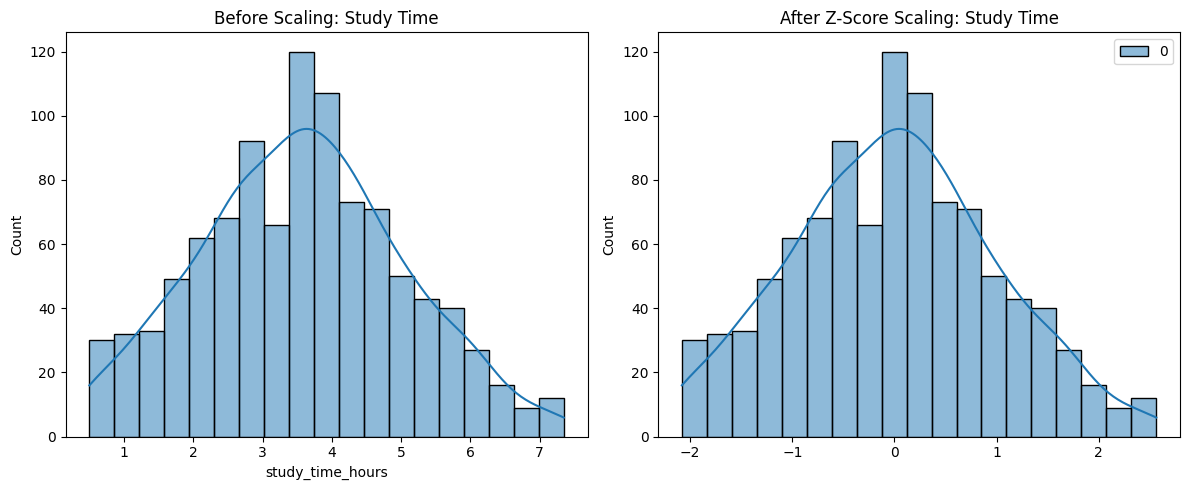

In [ ]:
# 17 & 18. Visualize distribution before and after preprocessing
scaler = StandardScaler()
scaled_study_time = scaler.fit_transform(df[['study_time_hours']])

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['study_time_hours'], kde=True, ax=ax[0])
ax[0].set_title("Before Scaling: Study Time")

sns.histplot(scaled_study_time, kde=True, ax=ax[1])
ax[1].set_title("After Z-Score Scaling: Study Time")
plt.tight_layout()
plt.show()

# 15. Split dataset into training and testing sets
X = df.drop(columns=['student_id', 'final_grade'])
y = df['final_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Model Training with SMOTE & Evaluation

Accuracy Score: 89.00%

              precision    recall  f1-score   support

           A       0.93      0.98      0.96        57
           B       0.91      0.87      0.89        71
           C       0.88      0.85      0.86        52
           D       0.76      0.89      0.82        18
           F       0.00      0.00      0.00         2

    accuracy                           0.89       200
   macro avg       0.70      0.72      0.71       200
weighted avg       0.89      0.89      0.89       200



<Figure size 800x600 with 0 Axes>

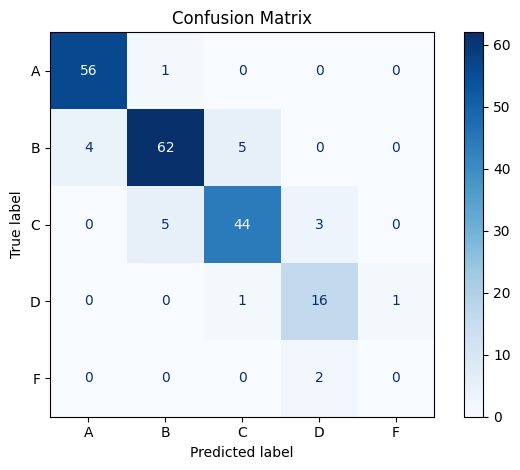

In [ ]:
# 8 & 9. Categorical encoding and feature scaling within pipeline
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

numeric_transformer = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# 16. Apply SMOTE and Train Model
model = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', SVC(kernel='rbf', C=2, gamma='scale'))
])

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2%}\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()